In [ ]:
# ==========================================================
# STEP 1: Mount Google Drive
# ==========================================================
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import tensorflow as tf

backup_folder = '/content/drive/MyDrive/thesis_densenet121_outputs'
model = tf.keras.models.load_model(f'{backup_folder}/best_densenet121_model.keras')
print("Saved model loaded successfully")

Saved model loaded successfully


In [ ]:
# ==========================================================
# STEP 2: Verify required files exist in Drive
# ==========================================================
import os

split_zip_path = '/content/drive/MyDrive/split_dataset.zip'
csv_zip_path = '/content/drive/MyDrive/thesis_dataset_csv-20260716T043638Z-1-001.zip'

print("split_dataset.zip exists:", os.path.exists(split_zip_path))
print("csv zip exists:", os.path.exists(csv_zip_path))

# If either prints False, remount the drive (shortcut may not be visible yet)
# from google.colab import drive
# drive.flush_and_unmount()
# drive.mount('/content/drive', force_remount=True)

split_dataset.zip exists: True
csv zip exists: True


In [ ]:
# ==========================================================
# STEP 3: Copy and extract the split dataset (images)
# ==========================================================
import shutil
import zipfile

shutil.copy(split_zip_path, '/content/split_dataset.zip')

with zipfile.ZipFile('/content/split_dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("Image dataset extracted!")

Image dataset extracted!


In [ ]:
# ==========================================================
# STEP 4: Extract the CSV zip and locate the actual CSV files
# ==========================================================
import os
import zipfile

with zipfile.ZipFile(csv_zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/csv_data')

for root, dirs, files in os.walk('/content/csv_data'):
    for f in files:
        print(os.path.join(root, f))

/content/csv_data/thesis_dataset_csv/val_data.csv
/content/csv_data/thesis_dataset_csv/train_data.csv
/content/csv_data/thesis_dataset_csv/test_data.csv


In [ ]:
# ==========================================================
# STEP 5 (corrected): Load CSVs and fix the file paths
# ==========================================================
import pandas as pd

train_df = pd.read_csv('/content/csv_data/thesis_dataset_csv/train_data.csv')
val_df   = pd.read_csv('/content/csv_data/thesis_dataset_csv/val_data.csv')
test_df  = pd.read_csv('/content/csv_data/thesis_dataset_csv/test_data.csv')

# Actual extraction created '/content/train', '/content/val', '/content/test' directly
# (no 'split_dataset' folder), so we simply remove that segment from the path.
for df in [train_df, val_df, test_df]:
    df['filepath'] = df['filepath'].str.replace(
        '/content/split_dataset', '/content'
    )

print("Sample file exists:", os.path.exists(train_df['filepath'].iloc[0]))
print("Train samples:", len(train_df))
print("Val samples:", len(val_df))
print("Test samples:", len(test_df))

Sample file exists: True
Train samples: 18037
Val samples: 2519
Test samples: 2538


In [ ]:
# ==========================================================
# STEP 6: Build tf.data pipelines
# ==========================================================
import tensorflow as tf

class_names = sorted(train_df['label'].unique())
num_classes = len(class_names)
label_to_index = {name: i for i, name in enumerate(class_names)}

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def load_and_preprocess(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    return img, label

def make_dataset(df, shuffle=False):
    filepaths = df['filepath'].values
    labels = df['label'].map(label_to_index).values
    labels = tf.keras.utils.to_categorical(labels, num_classes=num_classes)

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, shuffle=True)
val_ds   = make_dataset(val_df)
test_ds  = make_dataset(test_df)

print("Classes:", class_names)
print("Num classes:", num_classes)

Classes: ['Corn_Common_Rust', 'Corn_Gray_Leaf_Spot', 'Corn_Healthy', 'Corn_Leaf_Blight', 'Rice_Bacterial_Leaf_Blight', 'Rice_Brown_Spot', 'Rice_Healthy', 'Rice_Leaf_Blast', 'Wheat_Brown_Rust', 'Wheat_Healthy', 'Wheat_Loose_Smut', 'Wheat_Yellow_Rust']
Num classes: 12


In [ ]:
# ==========================================================
# STEP 7: Build DenseNet121 model (transfer learning)
# ==========================================================
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, models

base_model = DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = tf.keras.applications.densenet.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,302,988 (27.86 MB)

 Trainable params: 265,484 (1.01 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
# ==========================================================
# STEP 8: Set up callbacks (save results to Drive)
# ==========================================================
import os

backup_folder = '/content/drive/MyDrive/thesis_densenet121_outputs'
os.makedirs(backup_folder, exist_ok=True)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    f'{backup_folder}/best_densenet121_model.keras',
    save_best_only=True,
    monitor='val_accuracy'
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7
)
callbacks = [early_stop, checkpoint, reduce_lr]

In [ ]:
# ==========================================================
# STEP 9: Phase 1 training — train only the new top layers
# ==========================================================
history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
564/564 ━━━━━━━━━━━━━━━━━━━━ 129s 174ms/step - accuracy: 0.7955 - loss: 0.6014 - val_accuracy: 0.9087 - val_loss: 0.2727 - learning_rate: 0.0010
Epoch 2/10
564/564 ━━━━━━━━━━━━━━━━━━━━ 58s 103ms/step - accuracy: 0.8873 - loss: 0.3144 - val_accuracy: 0.9051 - val_loss: 0.2531 - learning_rate: 0.0010
Epoch 3/10
564/564 ━━━━━━━━━━━━━━━━━━━━ 59s 104ms/step - accuracy: 0.9092 - loss: 0.2530 - val_accuracy: 0.9301 - val_loss: 0.1984 - learning_rate: 0.0010
Epoch 4/10
564/564 ━━━━━━━━━━━━━━━━━━━━ 58s 103ms/step - accuracy: 0.9225 - loss: 0.2150 - val_accuracy: 0.9345 - val_loss: 0.1814 - learning_rate: 0.0010
Epoch 5/10
564/564 ━━━━━━━━━━━━━━━━━━━━ 57s 101ms/step - accuracy: 0.9308 - loss: 0.1847 - val_accuracy: 0.9329 - val_loss: 0.1834 - learning_rate: 0.0010
Epoch 6/10
564/564 ━━━━━━━━━━━━━━━━━━━━ 84s 105ms/step - accuracy: 0.9351 - loss: 0.1742 - val_accuracy: 0.9397 - val_loss: 0.1644 - learning_rate: 0.0010
Epoch 7/10
564/564 ━━━━━━━━━━━━━━━━━━━━ 84s 109ms/step - accuracy: 0.

In [ ]:
# ==========================================================
# STEP 10: Phase 2 training — fine-tune the last layers of DenseNet121
# ==========================================================
base_model.trainable = True

# Keep most of the base model frozen, unfreeze only the last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Use a much smaller learning rate for fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 133s 176ms/step - accuracy: 0.9000 - loss: 0.2995 - val_accuracy: 0.9440 - val_loss: 0.1627 - learning_rate: 1.0000e-05
Epoch 2/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 60s 106ms/step - accuracy: 0.9379 - loss: 0.1677 - val_accuracy: 0.9472 - val_loss: 0.1464 - learning_rate: 1.0000e-05
Epoch 3/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 64s 113ms/step - accuracy: 0.9460 - loss: 0.1432 - val_accuracy: 0.9488 - val_loss: 0.1377 - learning_rate: 1.0000e-05
Epoch 4/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 80s 109ms/step - accuracy: 0.9530 - loss: 0.1244 - val_accuracy: 0.9528 - val_loss: 0.1345 - learning_rate: 5.0000e-06
Epoch 5/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 64s 113ms/step - accuracy: 0.9531 - loss: 0.1230 - val_accuracy: 0.9536 - val_loss: 0.1321 - learning_rate: 5.0000e-06
Epoch 6/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 83s 114ms/step - accuracy: 0.9585 - loss: 0.1136 - val_accuracy: 0.9547 - val_loss: 0.1297 - learning_rate: 5.0000e-06
Epoch 7/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 79s 1

In [ ]:
# ==========================================================
# STEP 11: Evaluate on test set
# ==========================================================
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

with open(f'{backup_folder}/test_results.txt', 'w') as f:
    f.write(f"Test Loss: {test_loss:.4f}\n")
    f.write(f"Test Accuracy: {test_acc:.4f}\n")

print("Test results saved to Drive!")

80/80 ━━━━━━━━━━━━━━━━━━━━ 36s 241ms/step - accuracy: 0.9689 - loss: 0.0938
Test Loss: 0.0938
Test Accuracy: 0.9689
Test results saved to Drive!


1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

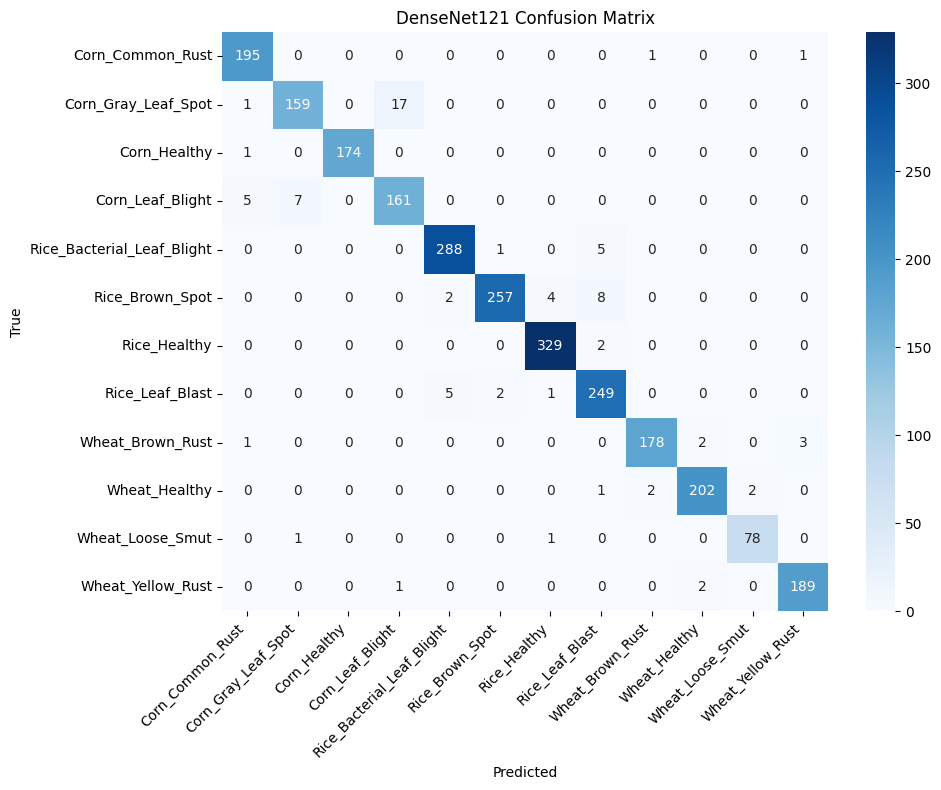

In [ ]:
# ==========================================================
# STEP 12: Classification report and confusion matrix
# ==========================================================
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

with open(f'{backup_folder}/classification_report.txt', 'w') as f:
    f.write(report)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('DenseNet121 Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{backup_folder}/confusion_matrix.png')
plt.show()

In [ ]:
# ==========================================================
# Single image prediction with confidence (DenseNet121)
# ==========================================================
from google.colab import files
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Upload image from your computer
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Load and preprocess
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# Predict
preds = model.predict(img_array)
pred_index = np.argmax(preds[0])
pred_class = class_names[pred_index]
confidence = preds[0][pred_index] * 100

# Display image with prediction
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis('off')
plt.title(f"{pred_class} ({confidence:.2f}%)")
plt.show()

print(f"Predicted class: {pred_class}")
print(f"Confidence: {confidence:.2f}%")

# Show top-3 predictions for extra context
top3_idx = np.argsort(preds[0])[::-1][:3]
print("\nTop 3 predictions:")
for idx in top3_idx:
    print(f"  {class_names[idx]}: {preds[0][idx]*100:.2f}%")

In [ ]:
# ==========================================================
# Model size, parameters, and inference time (for comparison table)
# ==========================================================
import os
import time
import numpy as np

# ---- 1. Model file size ----
model_path = f'{backup_folder}/best_densenet121_model.keras'
model_size_mb = os.path.getsize(model_path) / (1024 * 1024)
print(f"Model file size: {model_size_mb:.2f} MB")

# ---- 2. Parameter counts ----
total_params = model.count_params()
trainable_params = sum(np.prod(v.shape) for v in model.trainable_weights)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {int(trainable_params):,}")

# ---- 3. Average inference time per image ----
# Warm-up run (first call is always slower due to graph tracing)
dummy_input = np.random.rand(1, 224, 224, 3).astype(np.float32)
_ = model.predict(dummy_input, verbose=0)

n_runs = 100
times = []

for _ in range(n_runs):
    start = time.time()
    _ = model.predict(dummy_input, verbose=0)
    end = time.time()
    times.append((end - start) * 1000)  # convert to ms

avg_inference_time = np.mean(times)
print(f"Average inference time: {avg_inference_time:.2f} ms/image")




Model file size: 36.25 MB
Total parameters: 7,302,988
Trainable parameters: 906,892
Average inference time: 95.52 ms/image
